# Theorem 1 — multi-corpus trigram vocabulary-drift sweep

This notebook runs the **Theorem 1 vocabulary-reduction simulations** across multiple literary/scientific corpora.

It compares two regimes:

1. **Fixed-size live corpus** (`fixed_size_mix`)  
   Each generation keeps the total token budget fixed and replaces an `alpha` fraction of the original corpus with trigram-generated text.

2. **Growing corpus** (`growing_corpus`)  
   The original corpus remains, while machine-generated text accumulates each generation.

The notebook is designed for:
- **Arthur Conan Doyle**
- **Jane Austen**
- **Charles Darwin**

and uses the helper module `theorem1_vocab_drift.py`.

## Outputs

The notebook writes to the theorem-1 output tree under the project:

- combined multi-corpus metrics CSVs
- baseline corpus summaries
- appendix-ready comparison plots
- a final-generation summary table
- an SQLite experiment log (shared with the first notebook)

The key quantities tracked are:

- `vocab_size`
- `head_vocab_size` (words appearing in the head of observed trigrams)
- `trigram_type_count`
- `token_entropy_bits`
- `active_vocab_gt_1_over_M0` (for growing-corpus runs)

For fixed-size runs, the raw vocabulary size is informative.  
For growing-corpus runs, the *active vocabulary above the baseline threshold* is often more informative than raw vocabulary size.

In [1]:
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path


def _import_helper_module():
    here = Path.cwd().resolve()
    candidates = [here, *here.parents]
    helper_paths = []
    for cand in candidates:
        helper_paths.append(cand / "theorem1_vocab_drift.py")
        helper_paths.append(cand / "src" / "drift_selection" / "theorem1_vocab_drift.py")
        helper_paths.append(cand / "GitHub" / "src" / "drift_selection" / "theorem1_vocab_drift.py")
    for path in helper_paths:
        if path.exists():
            spec = importlib.util.spec_from_file_location("theorem1_vocab_drift", path)
            module = importlib.util.module_from_spec(spec)
            assert spec and spec.loader
            sys.modules["theorem1_vocab_drift"] = module
            spec.loader.exec_module(module)
            return module
    raise FileNotFoundError("Could not locate theorem1_vocab_drift.py")


mod = _import_helper_module()
print("Imported helper from:", Path(mod.__file__).resolve())

Imported helper from: /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/src/drift_selection/theorem1_vocab_drift.py


In [2]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

plt.rcParams["figure.figsize"] = (9, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["savefig.dpi"] = 180

paths = mod.default_paths()
multi_out = mod.ensure_dir(paths["outputs"] / "multi_corpus_alpha_sweep")
multi_fig = mod.ensure_dir(paths["figures"] / "theorem1_multi_corpus")
multi_tables = mod.ensure_dir(multi_out / "tables")
multi_metrics = mod.ensure_dir(multi_out / "metrics")

paths, multi_out

({'root': PosixPath('/Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection'),
  'github': PosixPath('/Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub'),
  'corpora': PosixPath('/Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora'),
  'raw': PosixPath('/Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora/raw'),
  'cleaned': PosixPath('/Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora/cleaned'),
  'notebooks': PosixPath('/Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/notebooks/active'),
  'outputs': PosixPath('/Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/data/outputs/theorem1_vocabulary_drift'),
  'runs': PosixPath('/Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/data/outputs/theorem1_vocabulary_drift/runs'),
  'metrics': PosixPath('/Users/sorenriis/Documents/ChatGpt_codex

## Configuration

You can change:
- corpus list
- alpha grids
- generations
- whether to save full trigram tables

For first runs, keep `save_full_trigram_tables=False`.

In [3]:
# Fast pilot: Conan Doyle only
CORPORA = ["conan_doyle", "jane_austen", "charles_darwin"]

FIXED_ALPHAS = [0.0, 0.25, 0.5, 1]
GROWING_ALPHAS = [0.05, 0.1, 0.25, 0.5]  # kept defined even if not used

FIXED_GENERATIONS = 12
GROWING_GENERATIONS = 4

BASE_SEED = 12345
LOWERCASE_TOKENS = True
SAVE_FULL_TRIGRAM_TABLES = False

RUN_FIXED = True
RUN_GROWING = False



## Build or download the corpora

Conan Doyle can use an already cleaned local file if present.  
Austen and Darwin can be auto-downloaded from Project Gutenberg if the raw texts are missing.

In [4]:
clean_paths = {}
corpus_sentences = {}
corpus_labels = {}

for author_key in CORPORA:
    clean_paths[author_key] = mod.build_or_download_author_corpus(author_key, force_download_missing=True)
    corpus_sentences[author_key] = mod.load_clean_corpus(author_key, lowercase=globals().get("LOWERCASE_TOKENS", True), progress_bar=True)
    corpus_labels[author_key] = mod.CORPUS_REGISTRY[author_key].label
    print(f"{author_key:15s} -> {clean_paths[author_key]}")

[corpus] Found existing cleaned corpus, reusing: /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora/cleaned/conan_doyle/conan_doyle_combined_clean.txt
[corpus] Found existing cleaned corpus, reusing: /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora/cleaned/conan_doyle/conan_doyle_combined_clean.txt
[corpus] Parsing cleaned corpus into sentences: /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora/cleaned/conan_doyle/conan_doyle_combined_clean.txt


sentence-parse:   0%|          | 0/77230 [00:00<?, ?block/s]

conan_doyle     -> /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora/cleaned/conan_doyle/conan_doyle_combined_clean.txt
[corpus] Found existing cleaned corpus, reusing: /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora/cleaned/jane_austen/jane_austen_combined_clean.txt
[corpus] Found existing cleaned corpus, reusing: /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora/cleaned/jane_austen/jane_austen_combined_clean.txt
[corpus] Parsing cleaned corpus into sentences: /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora/cleaned/jane_austen/jane_austen_combined_clean.txt


sentence-parse:   0%|          | 0/8676 [00:00<?, ?block/s]

jane_austen     -> /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora/cleaned/jane_austen/jane_austen_combined_clean.txt
[corpus] Found existing cleaned corpus, reusing: /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora/cleaned/charles_darwin/charles_darwin_combined_clean.txt
[corpus] Found existing cleaned corpus, reusing: /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora/cleaned/charles_darwin/charles_darwin_combined_clean.txt
[corpus] Parsing cleaned corpus into sentences: /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora/cleaned/charles_darwin/charles_darwin_combined_clean.txt


sentence-parse:   0%|          | 0/1840 [00:00<?, ?block/s]

charles_darwin  -> /Users/sorenriis/Documents/ChatGpt_codex_folder/Drift_and_selection/GitHub/corpora/cleaned/charles_darwin/charles_darwin_combined_clean.txt


## Baseline summaries for each corpus

In [5]:
baseline_rows = []

for author_key in CORPORA:
    sentences = corpus_sentences[author_key]
    metrics_df, top_words_df, top_trigrams_df = mod.summarize_corpus(sentences, top_k=25)
    row = metrics_df.iloc[0].to_dict()
    row["corpus_key"] = author_key
    row["corpus_label"] = corpus_labels[author_key]
    baseline_rows.append(row)

    top_words_df.to_csv(multi_tables / f"{author_key}_top_words.csv", index=False)
    top_trigrams_df.to_csv(multi_tables / f"{author_key}_top_trigrams.csv", index=False)

baseline_df = pd.DataFrame(baseline_rows).sort_values("corpus_label")
baseline_df.to_csv(multi_tables / "baseline_corpus_summary.csv", index=False)
baseline_df

,token_count,vocab_size,head_vocab_size,distinct_bigram_contexts,trigram_type_count,hapax_count,token_entropy_bits,active_vocab_gt_1_over_M0,active_count_threshold,corpus_key,corpus_label
0,4012543.0,55391.0,55391.0,742871.0,1881079.0,16718.0,9.800527,38673.0,2.0,conan_doyle,Arthur Conan Doyle
2,355826.0,15626.0,15626.0,136178.0,260888.0,6143.0,9.622409,9483.0,2.0,charles_darwin,Charles Darwin
1,601081.0,13929.0,13929.0,176871.0,409563.0,4842.0,9.258989,9087.0,2.0,jane_austen,Jane Austen


In [6]:
def run_mode_for_all_corpora(
    corpora: list[str],
    mode: str,
    alphas: list[float],
    generations: int,
    base_seed: int,
):
    frames = []
    for i, author_key in enumerate(tqdm(corpora, desc=f"corpus-sweep:{mode}", unit="corpus")):
        print(f"Running {mode} for {author_key} ...")
        df = mod.run_alpha_grid(
            anchor_sentences=corpus_sentences[author_key],
            corpus_name=author_key,
            alphas=alphas,
            generations=generations,
            mode=mode,
            base_seed=base_seed + 1000 * i,
            save_full_trigram_tables=SAVE_FULL_TRIGRAM_TABLES,
            paths=paths,
            run_name=f"theorem1_multi_{author_key}_{mode}_g{generations}",
            resume=True,
            force_rebuild=False,
            progress_bar=True,
        )
        df["corpus_key"] = author_key
        df["corpus_label"] = corpus_labels[author_key]
        frames.append(df)
    out = pd.concat(frames, ignore_index=True)
    return out


def add_retention_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    baseline = (
        df[df["generation"] == 0]
        .set_index(["corpus_key", "alpha"])[["vocab_size", "head_vocab_size", "trigram_type_count", "token_entropy_bits"]]
    )
    rows = []
    for _, row in df.iterrows():
        key = (row["corpus_key"], row["alpha"])
        base = baseline.loc[key]
        row = row.to_dict()
        for metric in ["vocab_size", "head_vocab_size", "trigram_type_count", "token_entropy_bits"]:
            denom = float(base[metric]) if float(base[metric]) != 0.0 else 1.0
            row[f"{metric}_retention"] = float(row[metric]) / denom
        rows.append(row)
    return pd.DataFrame(rows)


def final_generation_table(df: pd.DataFrame) -> pd.DataFrame:
    last_gen = int(df["generation"].max())
    out = df[df["generation"] == last_gen].copy()
    keep = [
        "corpus_key", "corpus_label", "mode", "alpha", "generation",
        "token_count", "vocab_size", "vocab_size_retention",
        "head_vocab_size", "head_vocab_size_retention",
        "trigram_type_count", "trigram_type_count_retention",
        "token_entropy_bits", "token_entropy_bits_retention",
    ]
    if "active_vocab_gt_1_over_M0" in out.columns:
        keep.append("active_vocab_gt_1_over_M0")
    return out[keep].sort_values(["mode", "corpus_label", "alpha"])


def plot_multi_corpus_metric(df: pd.DataFrame, metric: str, title: str, out_name: str):
    corpora = list(df["corpus_label"].drop_duplicates())
    fig, axes = plt.subplots(1, len(corpora), figsize=(5.4 * len(corpora), 4.7), sharey=False)
    if len(corpora) == 1:
        axes = [axes]
    for ax, corpus_label in zip(axes, corpora):
        sub = df[df["corpus_label"] == corpus_label]
        for alpha, alpha_df in sorted(sub.groupby("alpha"), key=lambda x: x[0]):
            ax.plot(alpha_df["generation"], alpha_df[metric], marker="o", label=f"α={alpha:g}")
        ax.set_title(corpus_label)
        ax.set_xlabel("generation")
        ax.set_ylabel(metric.replace("_", " "))
        ax.grid(alpha=0.3)
    axes[0].legend(title="mixture", loc="best")
    fig.suptitle(title, y=1.02, fontsize=14)
    fig.tight_layout()
    fig.savefig((multi_fig / out_name).with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig((multi_fig / out_name).with_suffix(".png"), bbox_inches="tight")
    return fig

## Run the fixed-size live-corpus simulations

In [7]:
fixed_all = None
if RUN_FIXED:
    fixed_all = run_mode_for_all_corpora(
        corpora=CORPORA,
        mode="fixed_size_mix",
        alphas=FIXED_ALPHAS,
        generations=FIXED_GENERATIONS,
        base_seed=BASE_SEED,
    )
    fixed_all["mode"] = "fixed_size_mix"
    fixed_all = add_retention_columns(fixed_all)
    fixed_all.to_csv(multi_metrics / "multi_corpus_fixed_size_metrics.csv", index=False)

fixed_all.head() if fixed_all is not None else None

corpus-sweep:fixed_size_mix:   0%|          | 0/3 [00:00<?, ?corpus/s]

Running fixed_size_mix for conan_doyle ...


alpha-grid:conan_doyle:fixed_size_mix:   0%|          | 0/4 [00:00<?, ?alpha/s]

[grid] Skipping completed alpha=0 for theorem1_multi_conan_doyle_fixed_size_mix_g12
[grid] Skipping completed alpha=0.25 for theorem1_multi_conan_doyle_fixed_size_mix_g12
[grid] Skipping completed alpha=0.5 for theorem1_multi_conan_doyle_fixed_size_mix_g12
[run] Started new run_id=30 (theorem1_multi_conan_doyle_fixed_size_mix_g12__alpha_1)


fixed_size_mix:conan_doyle:alpha=1:   0%|          | 0/13 [00:00<?, ?gen/s]

...

generate-synthetic:   0%|          | 0/355826 [00:00<?, ?tok/s]

generate-synthetic:   0%|          | 0/355826 [00:00<?, ?tok/s]

generate-synthetic:   0%|          | 0/355826 [00:00<?, ?tok/s]

generate-synthetic:   0%|          | 0/355826 [00:00<?, ?tok/s]

,run_id,generation,token_count,vocab_size,head_vocab_size,distinct_bigram_contexts,trigram_type_count,hapax_count,token_entropy_bits,active_vocab_gt_1_over_M0,active_count_threshold,alpha,mode,corpus_name,corpus_key,corpus_label,vocab_size_retention,head_vocab_size_retention,trigram_type_count_retention,token_entropy_bits_retention
0,21,0,4012543,55391,55391,742871,1881079,16718,9.800527,38673,2,0.0,fixed_size_mix,conan_doyle,conan_doyle,Arthur Conan Doyle,1.000000,1.000000,1.000000,1.000000
1,21,1,4012543,47996,47996,572021,1367076,9525,9.793368,38471,2,0.0,fixed_size_mix,conan_doyle,conan_doyle,Arthur Conan Doyle,0.866495,0.866495,0.726751,0.999269
2,21,2,4012547,47747,47747,572174,1366058,9282,9.791578,38465,2,0.0,fixed_size_mix,conan_doyle,conan_doyle,Arthur Conan Doyle,0.861999,0.861999,0.726210,0.999087
3,21,3,4012548,47795,47795,570604,1364375,9429,9.790154,38366,2,0.0,fixed_size_mix,conan_doyle,conan_doyle,Arthur Conan Doyle,0.862866,0.862866,0.725315,0.998942
4,21,4,4012543,47870,47870,572768,1367555,9557,9.790725,38313,2,0.0,fixed_size_mix,conan_doyle,conan_doyle,Arthur Conan Doyle,0.864220,0.864220,0.727006,0.999000


In [8]:
if fixed_all is not None:
    fixed_final_df = final_generation_table(fixed_all)
    fixed_final_df.to_csv(multi_tables / "fixed_size_final_generation_table.csv", index=False)
    fixed_final_df


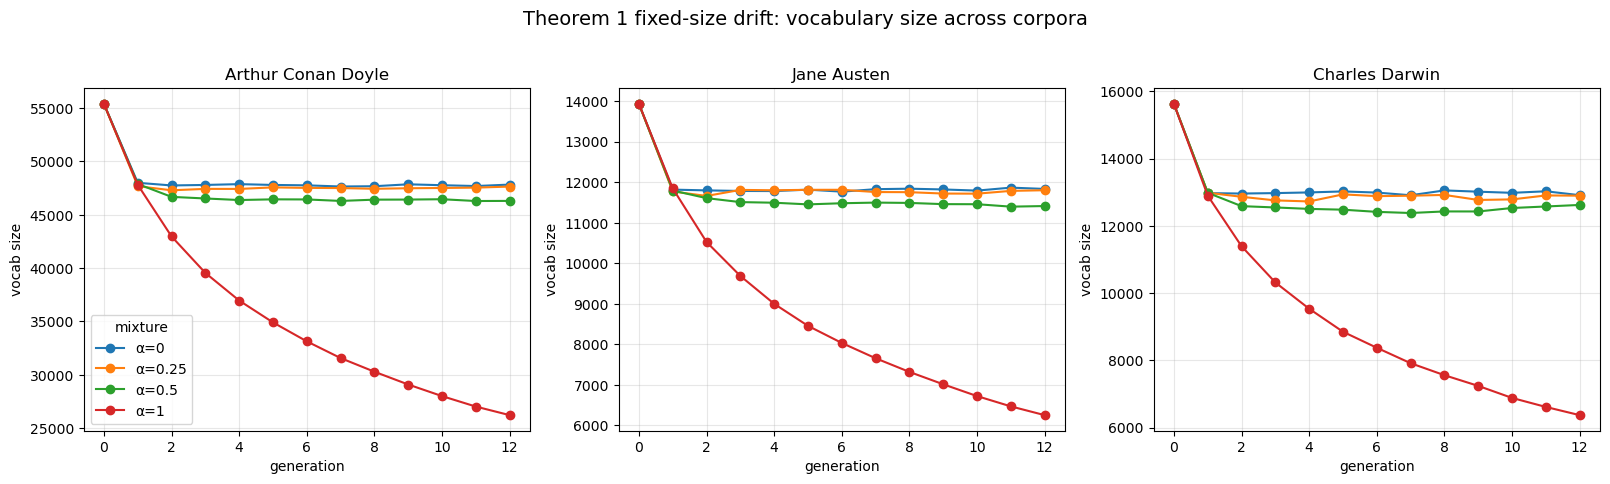

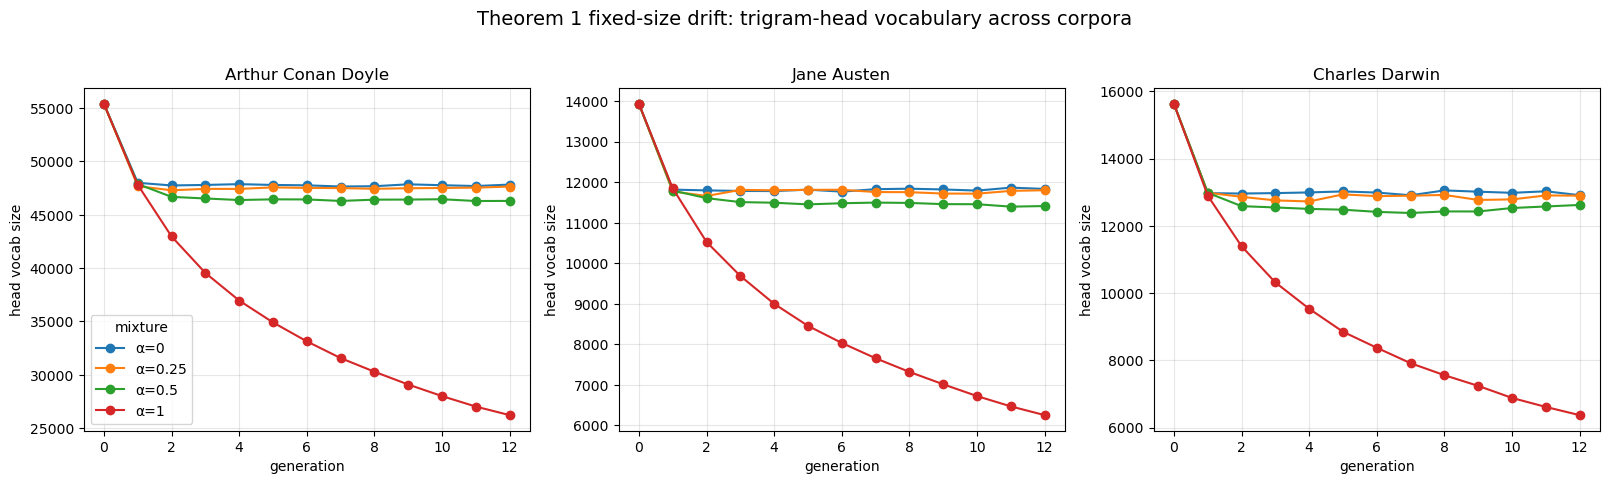

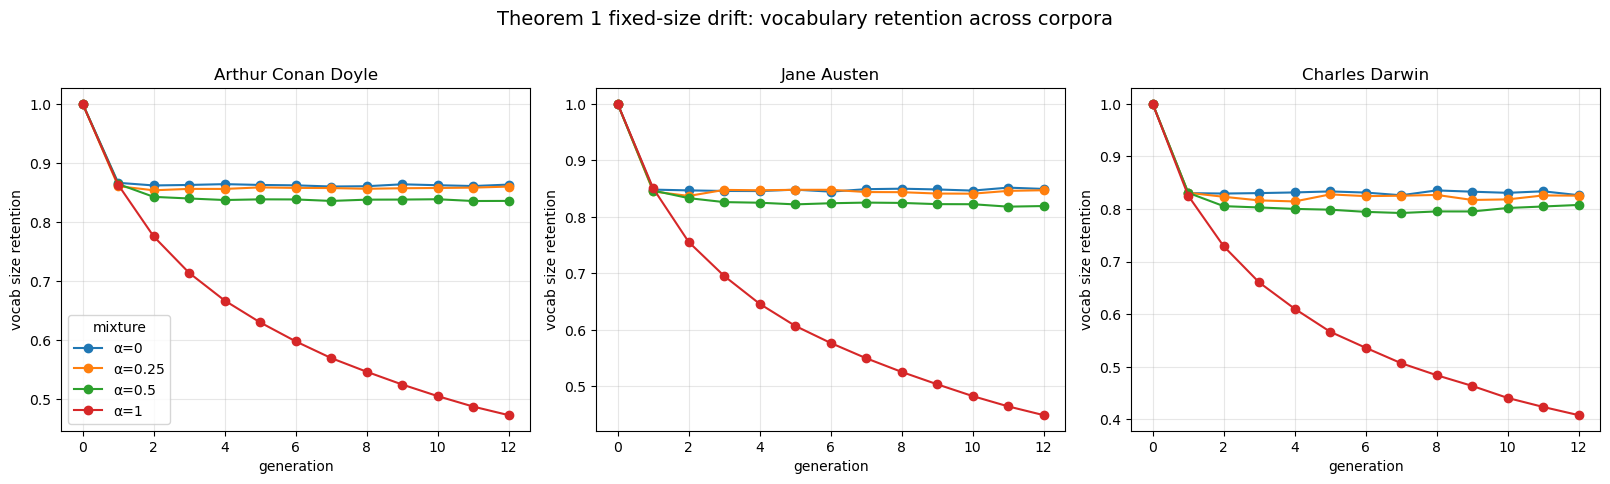

In [9]:
if fixed_all is not None:
    plot_multi_corpus_metric(
        fixed_all,
        metric="vocab_size",
        title="Theorem 1 fixed-size drift: vocabulary size across corpora",
        out_name="multi_corpus_fixed_vocab_size",
    )
    plt.show()

    plot_multi_corpus_metric(
        fixed_all,
        metric="head_vocab_size",
        title="Theorem 1 fixed-size drift: trigram-head vocabulary across corpora",
        out_name="multi_corpus_fixed_head_vocab",
    )
    plt.show()

    plot_multi_corpus_metric(
        fixed_all,
        metric="vocab_size_retention",
        title="Theorem 1 fixed-size drift: vocabulary retention across corpora",
        out_name="multi_corpus_fixed_vocab_retention",
    )
    plt.show()

## Run the growing-corpus simulations

In [10]:
growing_all = None
if RUN_GROWING:
    growing_all = run_mode_for_all_corpora(
        corpora=CORPORA,
        mode="growing_corpus",
        alphas=GROWING_ALPHAS,
        generations=GROWING_GENERATIONS,
        base_seed=BASE_SEED + 5000,
    )
    growing_all["mode"] = "growing_corpus"
    growing_all = add_retention_columns(growing_all)
    growing_all.to_csv(multi_metrics / "multi_corpus_growing_metrics.csv", index=False)

growing_all.head() if growing_all is not None else None

In [11]:
if growing_all is not None:
    growing_final_df = final_generation_table(growing_all)
    growing_final_df.to_csv(multi_tables / "growing_corpus_final_generation_table.csv", index=False)
    growing_final_df

In [12]:
if growing_all is not None:
    plot_multi_corpus_metric(
        growing_all,
        metric="vocab_size",
        title="Theorem 1 growing corpus: raw vocabulary size across corpora",
        out_name="multi_corpus_growing_vocab_size",
    )
    plt.show()

    if "active_vocab_gt_1_over_M0" in growing_all.columns:
        plot_multi_corpus_metric(
            growing_all,
            metric="active_vocab_gt_1_over_M0",
            title="Theorem 1 growing corpus: active vocabulary > 1/M0 across corpora",
            out_name="multi_corpus_growing_active_vocab",
        )
        plt.show()

    plot_multi_corpus_metric(
        growing_all,
        metric="head_vocab_size_retention",
        title="Theorem 1 growing corpus: trigram-head vocabulary retention across corpora",
        out_name="multi_corpus_growing_head_vocab_retention",
    )
    plt.show()

## Combined appendix-ready summary table

In [13]:
summary_frames = []
if fixed_all is not None:
    fixed_tag = final_generation_table(fixed_all).copy()
    fixed_tag["regime"] = "fixed_size_mix"
    summary_frames.append(fixed_tag)

if growing_all is not None:
    grow_tag = final_generation_table(growing_all).copy()
    grow_tag["regime"] = "growing_corpus"
    summary_frames.append(grow_tag)

if summary_frames:
    appendix_summary_df = pd.concat(summary_frames, ignore_index=True)
    appendix_summary_df.to_csv(multi_tables / "appendix_summary_table.csv", index=False)
    appendix_summary_df

## Inspect the SQLite registry and latest runs

In [14]:
with sqlite3.connect(paths["db"]) as conn:
    latest_runs_df = pd.read_sql_query(
        "SELECT * FROM runs ORDER BY run_id DESC LIMIT 30",
        conn,
    )
    latest_metrics_df = pd.read_sql_query(
        "SELECT * FROM generation_metrics ORDER BY run_id DESC, generation ASC LIMIT 40",
        conn,
    )

latest_runs_df.head(15)

,run_id,created_at,corpus_name,mode,alpha,generations,seed,notes,config_json
0,32,2026-03-05T08:33:23Z,charles_darwin,fixed_size_mix,1.00,12,14348,alpha-grid run for fixed_size_mix,"{""alpha"": 1.0, ""corpus_name"": ""charles_darwin""..."
1,31,2026-03-05T08:31:38Z,jane_austen,fixed_size_mix,1.00,12,13348,alpha-grid run for fixed_size_mix,"{""alpha"": 1.0, ""corpus_name"": ""jane_austen"", ""..."
2,30,2026-03-05T07:59:30Z,conan_doyle,fixed_size_mix,1.00,12,12348,alpha-grid run for fixed_size_mix,"{""alpha"": 1.0, ""corpus_name"": ""conan_doyle"", ""..."
3,29,2026-03-05T00:05:09Z,charles_darwin,fixed_size_mix,0.50,12,14347,alpha-grid run for fixed_size_mix,"{""alpha"": 0.5, ""corpus_name"": ""charles_darwin""..."
4,28,2026-03-05T00:04:14Z,charles_darwin,fixed_size_mix,0.25,12,14346,alpha-grid run for fixed_size_mix,"{""alpha"": 0.25, ""corpus_name"": ""charles_darwin..."
5,27,2026-03-05T00:03:26Z,charles_darwin,fixed_size_mix,0.00,12,14345,alpha-grid run for fixed_size_mix,"{""alpha"": 0.0, ""corpus_name"": ""charles_darwin""..."
6,26,2026-03-05T00:01:42Z,jane_austen,fixed_size_mix,0.50,12,13347,alpha-grid run for fixed_size_mix,"{""alpha"": 0.5, ""corpus_name"": ""jane_austen"", ""..."
7,25,2026-03-05T00:00:06Z,jane_austen,fixed_size_mix,0.25,12,13346,alpha-grid run for fixed_size_mix,"{""alpha"": 0.25, ""corpus_name"": ""jane_austen"", ..."
8,24,2026-03-04T23:58:44Z,jane_austen,fixed_size_mix,0.00,12,13345,alpha-grid run for fixed_size_mix,"{""alpha"": 0.0, ""corpus_name"": ""jane_austen"", ""..."
9,23,2026-03-04T23:30:18Z,conan_doyle,fixed_size_mix,0.50,12,12347,alpha-grid run for fixed_size_mix,"{""alpha"": 0.5, ""corpus_name"": ""conan_doyle"", ""..."


In [15]:
latest_metrics_df.head(20)

,run_id,generation,token_count,vocab_size,head_vocab_size,distinct_bigram_contexts,trigram_type_count,hapax_count,token_entropy_bits,active_vocab_gt_1_over_M0,active_count_threshold
0,32,0,355826,15626,15626,136178,260888,6143,9.622409,9483,2
1,32,1,355826,12896,12896,97675,174027,3123,9.584662,9773,2
2,32,2,355826,11392,11392,78357,133426,2072,9.546425,9320,2
3,32,3,355826,10315,10315,66303,109284,1480,9.526522,8835,2
4,32,4,355826,9533,9533,57832,92852,1146,9.504817,8387,2
5,32,5,355830,8849,8849,51348,80769,938,9.479587,7911,2
6,32,6,355827,8373,8373,46404,71748,810,9.454442,7563,2
7,32,7,355826,7914,7914,42353,64539,670,9.429507,7244,2
8,32,8,355826,7557,7557,39130,58860,614,9.414573,6943,2
9,32,9,355827,7239,7239,36412,54096,543,9.395491,6696,2


## Notes for Codex / repository placement

This notebook is intended to live at:

`Drift_and_selection/GitHub/notebooks/active/18_theorem1_multi_corpus_alpha_sweep.ipynb`

It depends on the helper module:

`Drift_and_selection/GitHub/src/drift_selection/theorem1_vocab_drift.py`

The notebook expects:
- Conan Doyle cleaned files to be discoverable locally if already present
- Austen and Darwin corpora to be auto-downloaded from Project Gutenberg if missing
- outputs under:
  - `GitHub/data/outputs/theorem1_vocabulary_drift/multi_corpus_alpha_sweep/`
- the shared SQLite database at:
  - `GitHub/data/databases/theorem1_vocabulary_drift.sqlite`